# Stress–Recovery Dynamics: A Coupled ODE Model

This notebook studies a **stylized educational dynamical system** with two coupled state variables. It was refactored from university coursework into a reproducible portfolio project.

> **Important:** the variables and thresholds in this model are abstract, dimensionless quantities. This is not a medical, psychological, or diagnostic model.

## 1. Model

We use

$$
\dot S(t)=\alpha E(t)-\beta R(t), \qquad
\dot R(t)=\gamma(S(t)-R(t)).
$$

- $S(t)$: response state
- $R(t)$: recovery/adaptation state
- $E(t)$: external forcing
- $\alpha>0$: response strength to forcing
- $\beta>0$: recovery feedback strength
- $\gamma>0$: adaptation rate

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.stress_recovery import (
    ModelParameters, constant_stressor, periodic_stressor, pulse_stressor,
    simulate_euler, simulate_ivp, equilibrium, stability_eigenvalues,
    time_above_threshold,
)

p = ModelParameters(alpha=1.0, beta=0.5, gamma=0.8)
time = np.linspace(0.0, 40.0, 801)

## 2. Equilibrium and stability

For constant forcing $E(t)=E_0$, equilibrium satisfies

$$S^*=R^*=\frac{\alpha E_0}{\beta}.$$

The Jacobian is

$$J=\begin{pmatrix}0&-\beta\\ \gamma&-\gamma\end{pmatrix},$$

with characteristic polynomial

$$\lambda^2+\gamma\lambda+\beta\gamma=0.$$

For $\beta>0$ and $\gamma>0$, the trace is negative and the determinant is positive, so both eigenvalues have negative real part and the equilibrium is asymptotically stable.

In [2]:
s_star, r_star = equilibrium(p, forcing_level=1.0)
eig = stability_eigenvalues(p)
print(f"Equilibrium for E0=1: S*={s_star:.3f}, R*={r_star:.3f}")
print("Jacobian eigenvalues:", eig)
print("Negative real parts:", np.all(np.real(eig) < 0))

Equilibrium for E0=1: S*=2.000, R*=2.000
Jacobian eigenvalues: [-0.4+0.48989795j -0.4-0.48989795j]
Negative real parts: True


## 3. Default periodic-forcing simulation

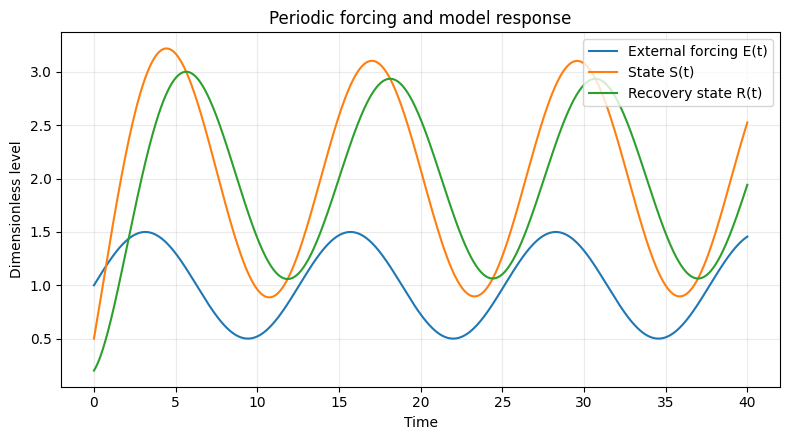

In [3]:
forcing, s, r = simulate_ivp(time, p, stressor=periodic_stressor)

plt.figure(figsize=(8, 4.5))
plt.plot(time, forcing, label="External forcing E(t)")
plt.plot(time, s, label="State S(t)")
plt.plot(time, r, label="Recovery state R(t)")
plt.xlabel("Time")
plt.ylabel("Dimensionless level")
plt.title("Periodic forcing and model response")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Explicit Euler vs. an adaptive reference solver

The original coursework used explicit Euler integration. Here the implementation is corrected so that the forcing is evaluated at the **start of the step** (`E[i-1]`). We compare it with `scipy.integrate.solve_ivp`.

Combined-state RMSE: 0.01699


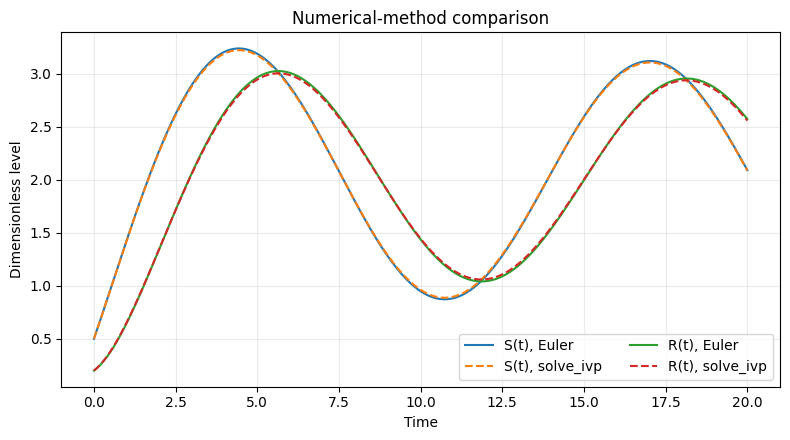

In [4]:
time_cmp = np.linspace(0.0, 20.0, 401)
_, s_euler, r_euler = simulate_euler(time_cmp, p)
_, s_ref, r_ref = simulate_ivp(time_cmp, p)
rmse = np.sqrt(np.mean((s_euler-s_ref)**2 + (r_euler-r_ref)**2))
print(f"Combined-state RMSE: {rmse:.5f}")

plt.figure(figsize=(8, 4.5))
plt.plot(time_cmp, s_euler, label="S(t), Euler")
plt.plot(time_cmp, s_ref, "--", label="S(t), solve_ivp")
plt.plot(time_cmp, r_euler, label="R(t), Euler")
plt.plot(time_cmp, r_ref, "--", label="R(t), solve_ivp")
plt.xlabel("Time")
plt.ylabel("Dimensionless level")
plt.title("Numerical-method comparison")
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## 5. Parameter sensitivity

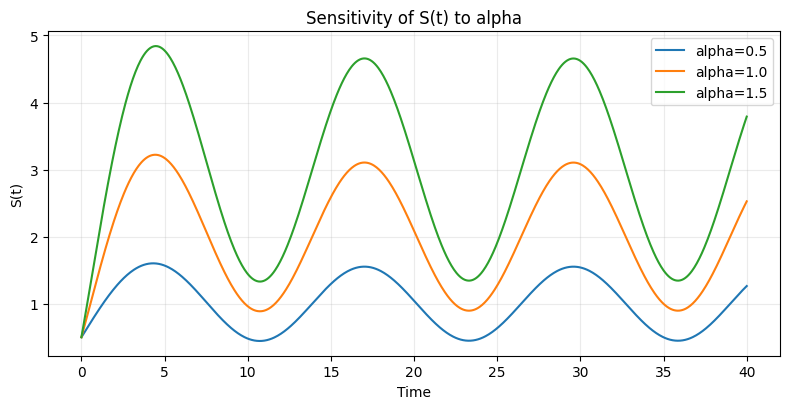

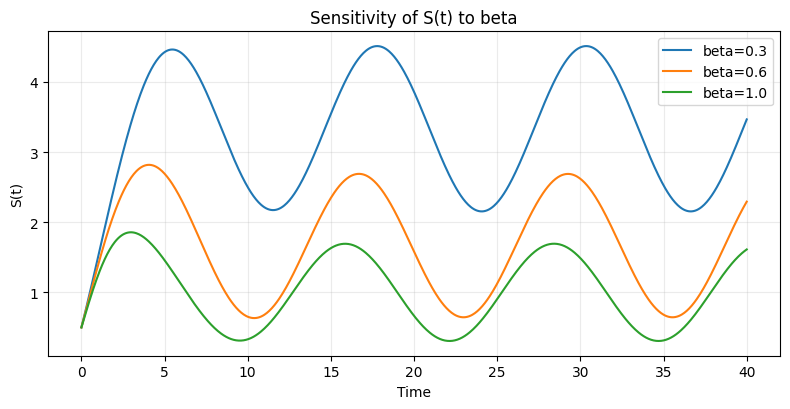

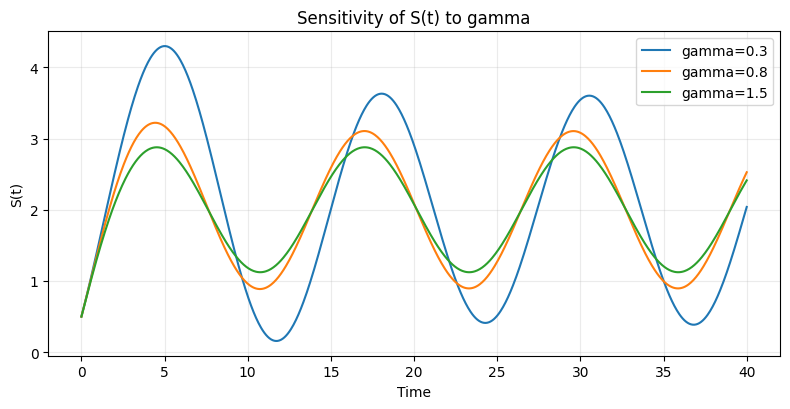

In [5]:
experiments = {
    "alpha": [0.5, 1.0, 1.5],
    "beta": [0.3, 0.6, 1.0],
    "gamma": [0.3, 0.8, 1.5],
}

for parameter_name, values in experiments.items():
    plt.figure(figsize=(8, 4.2))
    for value in values:
        kwargs = dict(alpha=p.alpha, beta=p.beta, gamma=p.gamma)
        kwargs[parameter_name] = value
        pp = ModelParameters(**kwargs)
        _, ss, _ = simulate_ivp(time, pp)
        plt.plot(time, ss, label=f"{parameter_name}={value}")
    plt.xlabel("Time")
    plt.ylabel("S(t)")
    plt.title(f"Sensitivity of S(t) to {parameter_name}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. External-forcing scenarios

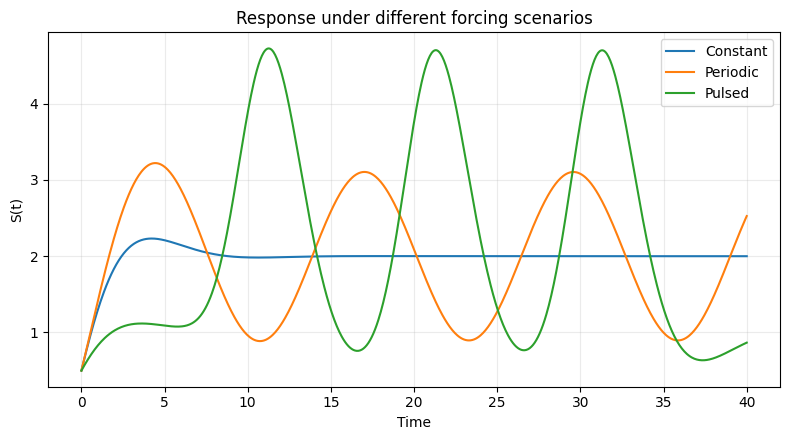

In [6]:
scenarios = {
    "Constant": constant_stressor,
    "Periodic": periodic_stressor,
    "Pulsed": pulse_stressor,
}

plt.figure(figsize=(8, 4.5))
for name, stressor in scenarios.items():
    _, ss, _ = simulate_ivp(time, p, stressor=stressor)
    plt.plot(time, ss, label=name)
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.title("Response under different forcing scenarios")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Illustrative parameter profiles

The profiles below are **not people or clinical categories**. They are simply three parameter combinations used to compare model behavior. The threshold is also illustrative.

Profile A: 0.00 time units above threshold
Profile B: 5.90 time units above threshold
Profile C: 21.05 time units above threshold


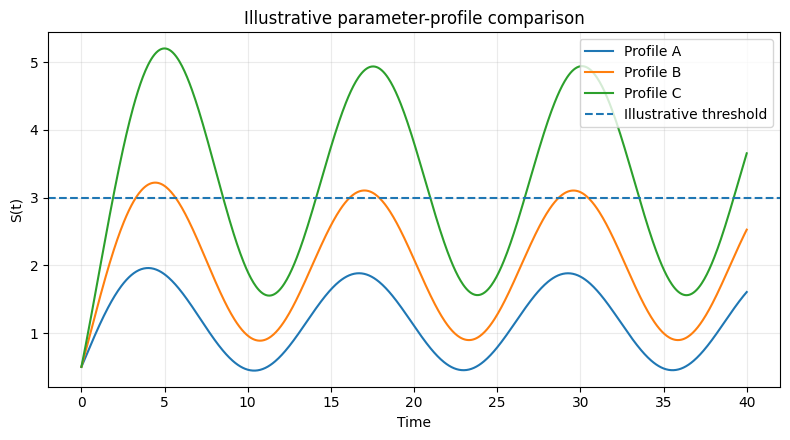

In [7]:
profiles = {
    "Profile A": ModelParameters(0.7, 0.6, 0.8),
    "Profile B": ModelParameters(1.0, 0.5, 0.8),
    "Profile C": ModelParameters(1.3, 0.4, 0.6),
}
threshold = 3.0

plt.figure(figsize=(8, 4.5))
for name, pp in profiles.items():
    _, ss, _ = simulate_ivp(time, pp)
    duration = time_above_threshold(time, ss, threshold)
    print(f"{name}: {duration:.2f} time units above threshold")
    plt.plot(time, ss, label=name)
plt.axhline(threshold, linestyle="--", label="Illustrative threshold")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.title("Illustrative parameter-profile comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Takeaways

- The constant-forcing equilibrium is available analytically and is asymptotically stable for positive `beta` and `gamma`.
- `alpha` raises sensitivity to external forcing, while `beta` strengthens the negative recovery feedback.
- `gamma` changes the adaptation time scale and therefore transient behavior.
- Constant, periodic, and pulsed forcing produce visibly different trajectories.
- Explicit Euler reproduces the reference solution reasonably well at a sufficiently small time step, but its numerical error is measurable.

### Limitations

This is a deliberately simplified two-state model. Its parameters are not fitted to human-subject data, the states are dimensionless, and no threshold used here should be interpreted as a clinical or psychological cutoff.